# 01 — Entendimento do Dataset PAD-UFES-20

> **Etapa 0 do refactor.** Este notebook não treina nada e não pré-processa nada.
> O objetivo é puramente *conhecer o terreno*: o problema clínico, a estrutura
> dos metadados, as imagens, as armadilhas e o que isso implica para as próximas
> etapas (extração de features por PDI e treinamento do modelo).

## O problema
Classificar lesões de pele em **6 categorias diagnósticas** a partir de
**imagens clínicas tiradas com smartphone** (não dermatoscópicas) e metadados
do paciente coletados no programa de assistência da UFES.

| Sigla | Nome | Tipo |
|---|---|---|
| **BCC** | Basal Cell Carcinoma | Maligno (mais comum) |
| **SCC** | Squamous Cell Carcinoma | Maligno (agressivo) |
| **MEL** | Melanoma | **Maligno — letal se tardio** |
| **ACK** | Actinic Keratosis | Pré-maligno |
| **NEV** | Nevus (pinta) | Benigno |
| **SEK** | Seborrheic Keratosis | Benigno (visualmente confunde com MEL) |

## Objetivo do refactor
Treinar um classificador a partir de **features extraídas por PDI**
(processamento digital de imagens) — cor, textura, forma, bordas — opcionalmente
combinadas com metadados clínicos. Não é objetivo deste notebook decidir o
modelo ainda; só entender o que temos.


## Setup

In [1]:
from pathlib import Path
import os, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)
random.seed(0); np.random.seed(0)

ROOT     = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'raw'
IMG_DIR  = DATA_DIR / 'images'
META     = DATA_DIR / 'metadata.csv'

assert META.exists(), f'metadata.csv não encontrado em {META}'
assert IMG_DIR.exists(), f'pasta de imagens não encontrada em {IMG_DIR}'
print('OK — dados em', DATA_DIR)


OK — dados em /home/fonsek/CODE/pad-ufes-skin-classification/data/raw


## 1. Metadados — visão geral

Antes de qualquer gráfico, queremos respostas para:

1. Quantas linhas e colunas?
2. Qual o tipo de cada coluna?
3. Quantos pacientes únicos? Quantas lesões? (uma lesão pode ter várias fotos,
   um paciente pode ter várias lesões → isso afeta como vamos splitar treino/teste).
4. Qual a distribuição da variável alvo?


In [2]:
df = pd.read_csv(META)
print('shape:', df.shape)
print('pacientes únicos :', df['patient_id'].nunique())
print('lesões únicas    :', df['lesion_id'].nunique())
print('imagens (linhas) :', len(df))
df.head(3)


shape: (2298, 26)
pacientes únicos : 1373
lesões únicas    : 1641
imagens (linhas) : 2298


,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,has_sewage_system,fitspatrick,region,diameter_1,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ARM,NaN,NaN,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,True,True,True,3.0,NECK,6.0,5.0,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FACE,NaN,NaN,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False


In [3]:
df.dtypes.to_frame('dtype').assign(n_unique=df.nunique().values)


,dtype,n_unique
patient_id,str,1373
lesion_id,int64,1641
smoke,object,2
drink,object,2
background_father,str,13
background_mother,str,11
age,int64,84
pesticide,object,2
gender,str,2
skin_cancer_history,object,2


**Leitura:** temos 2298 imagens distribuídas em 1641 lesões de
1373 pacientes. Isso significa que **há múltiplas imagens da mesma lesão** e
**vários pacientes com mais de uma lesão**. Quando formos dividir treino/teste
no futuro, o split tem que ser por **paciente** (não por imagem) para evitar
que o modelo "decore" um paciente.


## 2. Variável alvo — distribuição e desbalanceamento

In [4]:
CLASS_ORDER  = ['BCC', 'ACK', 'NEV', 'SEK', 'SCC', 'MEL']
CLASS_TYPE   = {'BCC':'maligno', 'SCC':'maligno', 'MEL':'maligno',
                'ACK':'pré-maligno', 'NEV':'benigno', 'SEK':'benigno'}
CLASS_COLORS = {'BCC':'#d62728', 'SCC':'#ff7f0e', 'MEL':'#8b0000',
                'ACK':'#bcbd22', 'NEV':'#2ca02c', 'SEK':'#17becf'}

counts = df['diagnostic'].value_counts().reindex(CLASS_ORDER)
pct    = (counts / counts.sum() * 100).round(1)
summary = pd.DataFrame({'n': counts, '%': pct, 'tipo': [CLASS_TYPE[c] for c in CLASS_ORDER]})
summary


,n,%,tipo
diagnostic,,,
BCC,845,36.8,maligno
ACK,730,31.8,pré-maligno
NEV,244,10.6,benigno
SEK,235,10.2,benigno
SCC,192,8.4,maligno
MEL,52,2.3,maligno


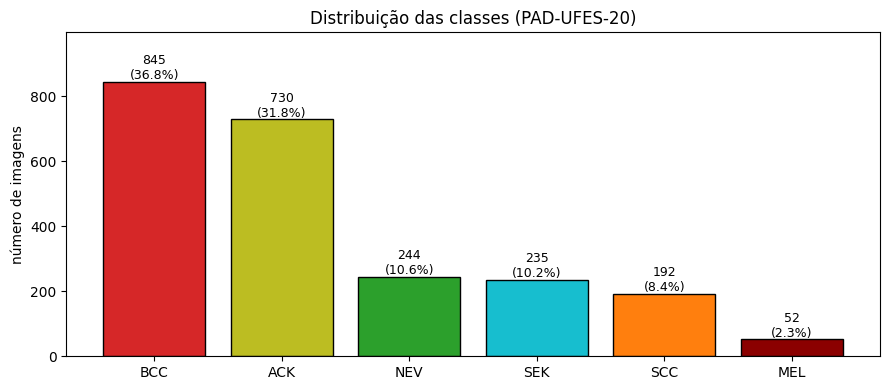

razão maior/menor classe: 16.2x


In [5]:
fig, ax = plt.subplots(figsize=(9,4))
colors = [CLASS_COLORS[c] for c in CLASS_ORDER]
bars = ax.bar(CLASS_ORDER, counts.values, color=colors, edgecolor='black')
for b, n, p in zip(bars, counts.values, pct.values):
    ax.text(b.get_x()+b.get_width()/2, n+8, f'{n}\n({p}%)', ha='center', fontsize=9)
ax.set_title('Distribuição das classes (PAD-UFES-20)')
ax.set_ylabel('número de imagens')
ax.set_ylim(0, counts.max()*1.18)
plt.tight_layout(); plt.show()

print(f'razão maior/menor classe: {counts.max()/counts.min():.1f}x')


**Implicação:** o dataset é fortemente desbalanceado.
A classe **MEL — o melanoma, justamente a mais letal — tem só 52 amostras**
(2.3%), contra 845 do BCC. Qualquer baseline ingênuo de acurácia será péssimo
para detectar melanoma. No futuro vamos precisar de:

- Métricas por classe (precisão/recall/F1 — não só accuracy)
- Estratégias para classe minoritária (class weights, oversampling, focal loss…)
- Atenção especial a **MEL recall** — falso negativo aqui pode custar uma vida


## 3. Estrutura paciente → lesão → imagem

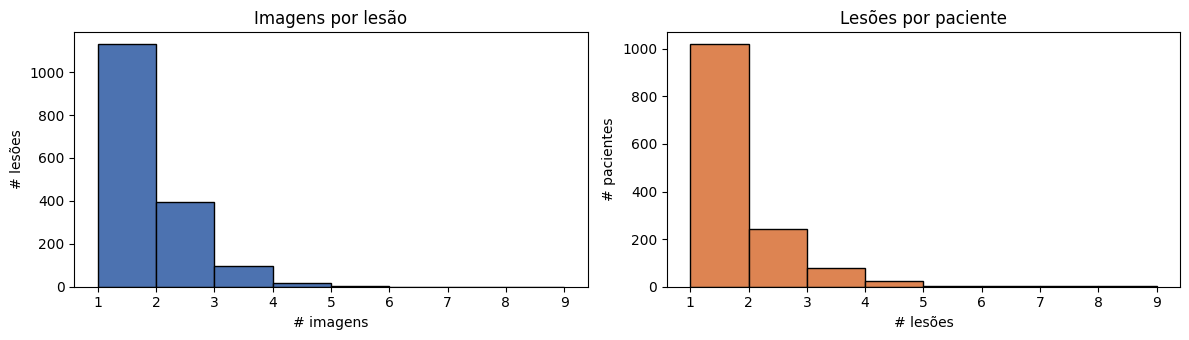

imagens/lesão  — média: 1.4 | max: 8
lesões/paciente— média: 1.38 | max: 8


In [6]:
imgs_per_lesion  = df.groupby('lesion_id').size()
lesions_per_pat  = df.groupby('patient_id')['lesion_id'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(imgs_per_lesion, bins=range(1, imgs_per_lesion.max()+2), color='#4c72b0', edgecolor='black')
axes[0].set_title('Imagens por lesão'); axes[0].set_xlabel('# imagens'); axes[0].set_ylabel('# lesões')
axes[1].hist(lesions_per_pat, bins=range(1, lesions_per_pat.max()+2), color='#dd8452', edgecolor='black')
axes[1].set_title('Lesões por paciente'); axes[1].set_xlabel('# lesões'); axes[1].set_ylabel('# pacientes')
plt.tight_layout(); plt.show()

print('imagens/lesão  — média:', round(imgs_per_lesion.mean(),2), '| max:', imgs_per_lesion.max())
print('lesões/paciente— média:', round(lesions_per_pat.mean(),2), '| max:', lesions_per_pat.max())


**Armadilha de vazamento:** se eu jogar todas as imagens num
`train_test_split` simples, é provável que duas fotos da mesma lesão (quase
idênticas) caiam uma no treino e outra no teste. Resultado: métricas infladas.
A solução padrão é split **agrupado por `patient_id`** (`GroupShuffleSplit` /
`StratifiedGroupKFold`). Anotado para a próxima etapa.


## 4. Valores ausentes

In [7]:
na = df.isna().sum()
na = na[na > 0].sort_values(ascending=False)
na_pct = (na / len(df) * 100).round(1)
pd.DataFrame({'nulos': na, '%': na_pct})


,nulos,%
background_mother,822,35.8
background_father,818,35.6
smoke,804,35.0
drink,804,35.0
pesticide,804,35.0
gender,804,35.0
skin_cancer_history,804,35.0
cancer_history,804,35.0
has_piped_water,804,35.0
has_sewage_system,804,35.0


In [8]:
# Os nulos são aleatórios ou concentrados em alguma classe?
nan_by_class = df.assign(any_na=df[na.index].isna().any(axis=1))                   .groupby('diagnostic')['any_na'].mean().reindex(CLASS_ORDER) * 100
nan_by_class.round(1).to_frame('% linhas com algum NaN')


,% linhas com algum NaN
diagnostic,
BCC,0.0
ACK,62.6
NEV,70.5
SEK,83.0
SCC,0.0
MEL,0.0


**Leitura:** 13 colunas têm exatamente **804 nulos (~35%)**
— isto é, há um bloco grande de pacientes onde quase nenhum metadado clínico
foi coletado, provavelmente uma sub-coleta diferente do dataset. Para esses
pacientes só temos a imagem e poucas variáveis. Decisões para depois:

- Se formos usar metadados, precisamos imputar (mas com cuidado: imputação só com
  estatística do treino).
- Como o objetivo é treinar **a partir das features de PDI da imagem**, a
  ausência de metadados é menos crítica — a imagem está sempre lá.


## 5. Features numéricas básicas (idade, diâmetros, fitzpatrick)

In [9]:
num_cols = ['age', 'diameter_1', 'diameter_2', 'fitspatrick']
df[num_cols].describe().round(2)


,age,diameter_1,diameter_2,fitspatrick
count,2298.00,1494.00,1494.00,1494.00
mean,60.46,11.90,8.85,2.27
std,15.89,8.63,5.80,0.73
min,6.00,0.00,0.00,1.00
25%,52.00,7.00,5.00,2.00
50%,62.00,10.00,8.00,2.00
75%,72.00,15.00,10.00,3.00
max,94.00,100.00,70.00,6.00


/tmp/ipykernel_432088/1860209630.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_age, labels=CLASS_ORDER, patch_artist=True)
/tmp/ipykernel_432088/1860209630.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_d, labels=CLASS_ORDER, patch_artist=True)


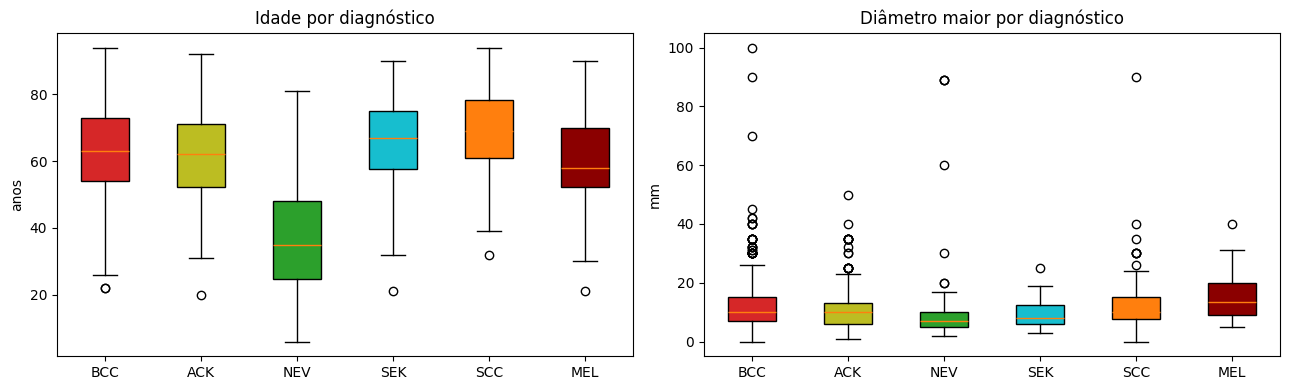

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# idade por classe
data_age = [df.loc[df['diagnostic']==c, 'age'].dropna() for c in CLASS_ORDER]
bp = axes[0].boxplot(data_age, labels=CLASS_ORDER, patch_artist=True)
for patch, c in zip(bp['boxes'], CLASS_ORDER):
    patch.set_facecolor(CLASS_COLORS[c])
axes[0].set_title('Idade por diagnóstico'); axes[0].set_ylabel('anos')

# diâmetro maior
data_d = [df.loc[df['diagnostic']==c, 'diameter_1'].dropna() for c in CLASS_ORDER]
bp = axes[1].boxplot(data_d, labels=CLASS_ORDER, patch_artist=True)
for patch, c in zip(bp['boxes'], CLASS_ORDER):
    patch.set_facecolor(CLASS_COLORS[c])
axes[1].set_title('Diâmetro maior por diagnóstico'); axes[1].set_ylabel('mm')
plt.tight_layout(); plt.show()


**Leitura:** a idade separa bem **NEV (~35 anos)** dos demais
(60–70). E os diâmetros são consistentemente maiores em malignos (BCC, SCC) —
sinal clínico clássico. Mas lembrar: `diameter_1` / `diameter_2` têm 35% de
NaN.


## 6. ⚠️ Armadilha do `biopsed` — possível data leakage

In [11]:
pd.crosstab(df['diagnostic'], df['biopsed'], margins=True)


biopsed,False,True,All
diagnostic,,,
ACK,552,178,730
BCC,0,845,845
MEL,0,52,52
NEV,184,60,244
SCC,0,192,192
SEK,220,15,235
All,956,1342,2298


**Crítico.** Toda lesão maligna (BCC, MEL, SCC) tem
`biopsed=True`. Em outras palavras: saber que houve biópsia já praticamente
diz que a lesão é maligna.

Mas isso é vazamento puro: na vida real você só pede biópsia **depois**
de já desconfiar. Um modelo que usa `biopsed` como feature está na verdade
"trapaceando", olhando o futuro.

**Decisão (para depois):** `biopsed` será removido das features do modelo.


## 7. Imagens — propriedades físicas

In [12]:
img_paths = sorted(glob.glob(str(IMG_DIR / '*.png')))
print('total de imagens em disco:', len(img_paths))
print('total de linhas no metadata:', len(df))

# checar consistência: toda linha aponta para um arquivo existente?
existing = {os.path.basename(p) for p in img_paths}
missing_files = df.loc[~df['img_id'].isin(existing), 'img_id']
print('linhas do metadata sem arquivo correspondente:', len(missing_files))


total de imagens em disco: 2298
total de linhas no metadata: 2298
linhas do metadata sem arquivo correspondente: 0


In [13]:
# Coletar dimensões de uma amostra grande (não vale ler 2298 imagens só pra histograma)
SAMPLE = 400
sample_paths = random.sample(img_paths, SAMPLE)
dims = []
for p in sample_paths:
    with Image.open(p) as im:
        dims.append((im.size[0], im.size[1], im.mode))
dim_df = pd.DataFrame(dims, columns=['w', 'h', 'mode'])
print(dim_df[['w','h']].describe().round(0))
print('\nmodos de cor:'); print(dim_df['mode'].value_counts())
print('\nformatos quadrados?', (dim_df['w']==dim_df['h']).mean())


            w       h
count   400.0   400.0
mean    894.0   894.0
std     516.0   516.0
min     147.0   147.0
25%     494.0   494.0
50%     753.0   756.0
75%    1162.0  1162.0
max    3120.0  3120.0

modos de cor:
mode
RGBA    252
RGB     148
Name: count, dtype: int64

formatos quadrados? 0.8175


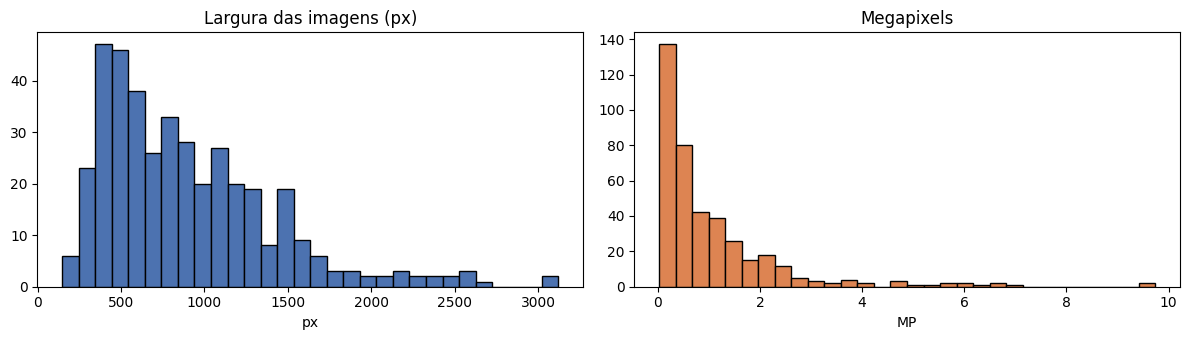

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(dim_df['w'], bins=30, color='#4c72b0', edgecolor='black')
axes[0].set_title('Largura das imagens (px)'); axes[0].set_xlabel('px')
axes[1].hist(dim_df['w']*dim_df['h']/1e6, bins=30, color='#dd8452', edgecolor='black')
axes[1].set_title('Megapixels'); axes[1].set_xlabel('MP')
plt.tight_layout(); plt.show()


**Leitura das imagens:**

- **Não são uniformes.** Vão de ~190px a ~3000px de lado, com mediana
  perto de 770px. Boa parte é quadrada mas nem todas.
- **Nem todas são RGB.** Algumas vêm como `RGBA` (têm canal alfa). Antes de
  qualquer extração de feature de PDI, vamos precisar converter tudo para um
  espaço de cor consistente (provavelmente RGB) e a um tamanho consistente.
- **Imagens clínicas, não dermatoscópicas.** Foram tiradas com smartphone,
  então têm iluminação variável, pelo, sombras, fundo de pele "normal" ao
  redor da lesão, às vezes a lesão nem está centralizada. PDI vai precisar
  lidar com isso (segmentação? recorte central? equalização de iluminação?).


## 8. Olhar de verdade — uma amostra por classe

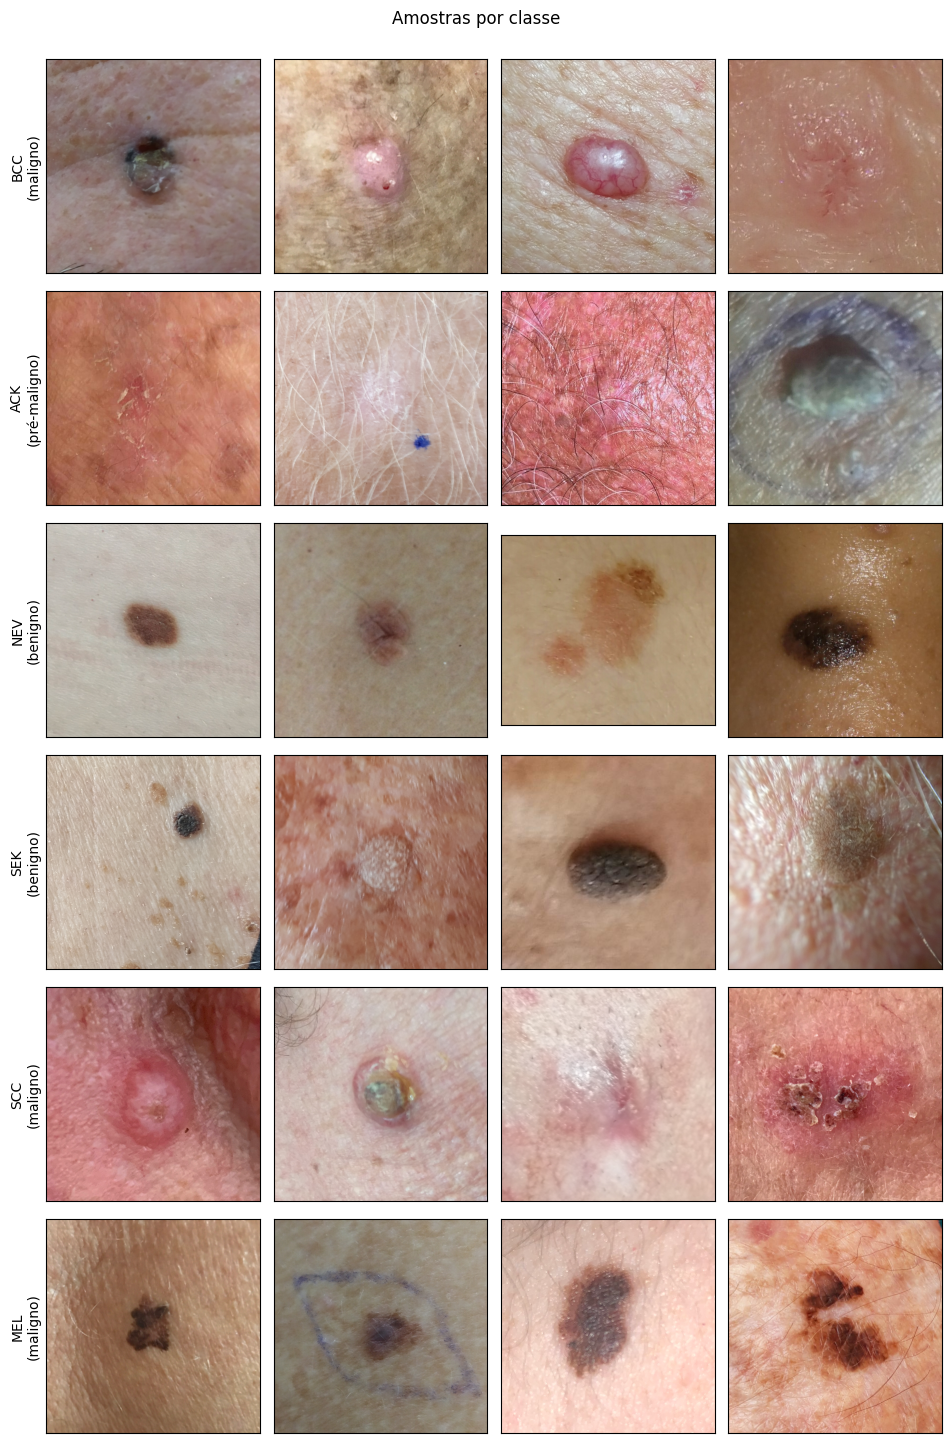

In [15]:
N_PER_CLASS = 4
fig, axes = plt.subplots(len(CLASS_ORDER), N_PER_CLASS, figsize=(N_PER_CLASS*2.4, len(CLASS_ORDER)*2.4))
for i, cls in enumerate(CLASS_ORDER):
    sub = df[df['diagnostic']==cls].sample(N_PER_CLASS, random_state=0)
    for j, (_, row) in enumerate(sub.iterrows()):
        ax = axes[i, j]
        with Image.open(IMG_DIR / row['img_id']) as im:
            ax.imshow(im)
        ax.set_xticks([]); ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(f'{cls}\n({CLASS_TYPE[cls]})', fontsize=10)
plt.suptitle('Amostras por classe', y=1.0)
plt.tight_layout(); plt.show()


**Observações qualitativas (olho clínico bem amador):**

- **BCC/SCC** muitas vezes com bordas irregulares, vermelhidão, crostas.
- **MEL** com variação de cor (preto/marrom/azul) e bordas assimétricas — o
  clássico "ABCDE".
- **NEV** geralmente arredondada, simétrica, cor uniforme.
- **SEK** lembra MEL visualmente — grude marrom/preto com superfície
  granulada. **É a confusão clássica** que queremos que nosso modelo aprenda
  a evitar.
- **ACK** áspera, descamativa, em pele já danificada pelo sol.

Tudo isso aponta para que **features de cor (variância, entropia HSV/LAB),
textura (GLCM, LBP) e forma (assimetria, perímetro, circularidade)** sejam
candidatos naturais a features de PDI.


## 9. Limitações e armadilhas (resumo)

| # | Limitação | Por que importa | Como tratar (depois) |
|---|---|---|---|
| 1 | **Desbalanceamento extremo** (MEL 2.3%) | Modelo vai ignorar a classe mais letal | class weights, oversampling, métricas por classe, foco em recall do MEL |
| 2 | **Múltiplas imagens / lesão e múltiplas lesões / paciente** | Split aleatório vaza informação entre treino/teste | Split agrupado por `patient_id` |
| 3 | **`biopsed` é leak** | Quase determinístico para malignidade | Remover das features |
| 4 | **35% de metadados ausentes** em bloco | Imputação só com estatística do treino; ou ignorar metadados e usar só imagem | Decidir na próxima etapa |
| 5 | **Imagens heterogêneas** (tamanho, modo, iluminação) | Features de PDI mudam radicalmente com escala/iluminação | Padronizar tamanho e espaço de cor antes de extrair features |
| 6 | **Imagens clínicas, não dermatoscópicas** | Pelo, fundo, sombra, lesão não centralizada | Considerar segmentação ou pré-processamento de iluminação |
| 7 | **Dataset pequeno (2298)** | Risco de overfit, especialmente com features ricas | Validação cruzada, regularização, manter modelo simples |

## 10. O que vem a seguir (próximos notebooks)

1. `02_pre_processamento_imagens.ipynb` — padronizar imagens (resize, RGB,
   possivelmente segmentação simples da lesão).
2. `03_extracao_features_pdi.ipynb` — extrair as features clássicas (cor,
   textura, forma, bordas) e salvar uma tabela tabular `(N, F)`.
3. `04_split_e_baseline.ipynb` — split estratificado por paciente, baseline
   com modelos clássicos sobre as features de PDI.
4. `05_modelo_e_avaliacao.ipynb` — modelo final, métricas por classe, matriz
   de confusão, análise de erros (especialmente SEK ↔ MEL).

Este notebook fica como **documento de referência** do que sabemos sobre o
dataset antes de tocar em qualquer transformação.
